In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

import time

In [2]:
PROJECT_ROOT = (
    Path.cwd()
    .parent
)

SRC_DIR = (
    PROJECT_ROOT
    / "src"
)

if str(PROJECT_ROOT) not in sys.path:

    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )

In [3]:
from src.data_pipeline import (
    list_ohlcv_files,
    load_ohlcv_data,
    analyse_ohlcv_data,
)

from src.supertrend_utils import (
    calculate_supertrend,
)

from src.strategy_engine import (
    generate_signals,
    backtest_strategy,
    calculate_performance,
)

from src.plotting_utils import (
    plot_ohlcv,
    plot_ohlcv_with_supertrend_bands,
    plot_ohlcv_with_supertrend,
    plot_strategy_trades,
    plot_cumulative_pnl,
    print_performance_summary,
    #plot_performance_ratios,
    plot_strategy_performance,
)

In [4]:
ohlcv_filepaths = (
    list_ohlcv_files()
)

for ohlcv_filepath in (
    ohlcv_filepaths
):

    print(
        ohlcv_filepath.name
    )

XAUUSD_M1_2023.csv
XAUUSD_M1_2024.csv
XAUUSD_M1_2025.csv
XAUUSD_M1_2026.csv


In [5]:
ohlcv_data = (
    load_ohlcv_data(
        filepaths=ohlcv_filepaths
    )
)

In [6]:
ohlcv_data.head()

,open,high,low,close,tick_volume,source_file
time,,,,,,
2023-03-20 14:31:00,1980.86,1981.13,1980.46,1980.58,85,XAUUSD_M1_2023.csv
2023-03-20 14:32:00,1980.58,1980.75,1979.68,1980.68,97,XAUUSD_M1_2023.csv
2023-03-20 14:33:00,1980.68,1980.70,1979.55,1979.58,74,XAUUSD_M1_2023.csv
2023-03-20 14:34:00,1979.48,1979.90,1979.15,1979.62,98,XAUUSD_M1_2023.csv
2023-03-20 14:35:00,1979.62,1980.65,1979.58,1980.30,101,XAUUSD_M1_2023.csv


In [7]:
ohlcv_data.tail()

,open,high,low,close,tick_volume,source_file
time,,,,,,
2026-07-03 19:55:00,4175.19,4175.72,4174.82,4175.72,52,XAUUSD_M1_2026.csv
2026-07-03 19:56:00,4175.72,4176.46,4175.46,4176.46,76,XAUUSD_M1_2026.csv
2026-07-03 19:57:00,4176.46,4176.46,4173.79,4174.02,88,XAUUSD_M1_2026.csv
2026-07-03 19:58:00,4174.04,4175.60,4173.80,4175.60,108,XAUUSD_M1_2026.csv
2026-07-03 19:59:00,4175.63,4175.90,4174.89,4174.94,88,XAUUSD_M1_2026.csv


In [253]:
start_time = time.time()
supertrend_data = (
    calculate_supertrend(
        ohlcv_data=ohlcv_data,
        atr_period=100,
        multiplier=3.0,
        smoothing_type="SMA",
    )
)
end_time = time.time()

supertrend_time = end_time - start_time
print(supertrend_time)

TypeError: calculate_supertrend() got an unexpected keyword argument 'smoothing_type'

In [232]:
supertrend_data.columns

Index(['open', 'high', 'low', 'close', 'tick_volume', 'source_file',
       'true_range', 'atr', 'basic_upper_band', 'basic_lower_band',
       'final_upper_band', 'final_lower_band', 'supertrend', 'trend'],
      dtype='str')

In [233]:
supertrend_data.head()

,open,high,low,close,tick_volume,source_file,true_range,atr,basic_upper_band,basic_lower_band,final_upper_band,final_lower_band,supertrend,trend
time,,,,,,,,,,,,,,
2023-03-20 14:31:00,1980.86,1981.13,1980.46,1980.58,85,XAUUSD_M1_2023.csv,0.67,0.670000,1982.805000,1978.785000,1982.805000,1978.785,1982.805000,-1.0
2023-03-20 14:32:00,1980.58,1980.75,1979.68,1980.68,97,XAUUSD_M1_2023.csv,1.07,0.672000,1982.231000,1978.199000,1982.231000,1978.785,1982.231000,-1.0
2023-03-20 14:33:00,1980.68,1980.70,1979.55,1979.58,74,XAUUSD_M1_2023.csv,1.15,0.674390,1982.148170,1978.101830,1982.148170,1978.785,1982.148170,-1.0
2023-03-20 14:34:00,1979.48,1979.90,1979.15,1979.62,98,XAUUSD_M1_2023.csv,0.75,0.674768,1981.549304,1977.500696,1981.549304,1978.785,1981.549304,-1.0
2023-03-20 14:35:00,1979.62,1980.65,1979.58,1980.30,101,XAUUSD_M1_2023.csv,1.07,0.676744,1982.145233,1978.084767,1981.549304,1978.785,1981.549304,-1.0


In [234]:
supertrend_data.tail()

,open,high,low,close,tick_volume,source_file,true_range,atr,basic_upper_band,basic_lower_band,final_upper_band,final_lower_band,supertrend,trend
time,,,,,,,,,,,,,,
2026-07-03 19:55:00,4175.19,4175.72,4174.82,4175.72,52,XAUUSD_M1_2026.csv,0.90,1.315802,4179.217407,4171.322593,4178.627237,4171.322593,4171.322593,1.0
2026-07-03 19:56:00,4175.72,4176.46,4175.46,4176.46,76,XAUUSD_M1_2026.csv,1.00,1.314223,4179.902670,4172.017330,4178.627237,4172.017330,4172.017330,1.0
2026-07-03 19:57:00,4176.46,4176.46,4173.79,4174.02,88,XAUUSD_M1_2026.csv,2.67,1.321002,4179.088007,4171.161993,4178.627237,4172.017330,4172.017330,1.0
2026-07-03 19:58:00,4174.04,4175.60,4173.80,4175.60,108,XAUUSD_M1_2026.csv,1.80,1.323397,4178.670192,4170.729808,4178.627237,4172.017330,4172.017330,1.0
2026-07-03 19:59:00,4175.63,4175.90,4174.89,4174.94,88,XAUUSD_M1_2026.csv,1.01,1.321830,4179.360491,4171.429509,4178.627237,4172.017330,4172.017330,1.0


In [235]:
start_time = time.time()

signal_data = (
    generate_signals(
        supertrend_data=supertrend_data,
        penetration_ticks=1,
        penetration_model="atr_frac",
        min_penetration_atr_fraction=1.0,
        volume_multiplier=3.0,
    )
)

end_time = time.time()
signal_time = end_time - start_time 

print(signal_time)

0.07850527763366699


In [236]:
signal_data[
    signal_data["long_signal"]
    |
    signal_data["short_signal"]
]

,open,high,low,close,tick_volume,source_file,true_range,atr,basic_upper_band,basic_lower_band,final_upper_band,final_lower_band,supertrend,trend,volume_ma,long_signal,short_signal,breakout_price,signal_strength
time,,,,,,,,,,,,,,,,,,,
2023-04-28 06:24:00,1989.40,1991.10,1987.84,1988.49,144,XAUUSD_M1_2023.csv,3.26,0.427448,1990.752343,1988.187657,1990.475161,1988.619994,1990.475161,-1.0,44.20,False,True,1991.10,0.999990
2023-04-28 07:00:00,1988.89,1990.32,1987.46,1987.70,189,XAUUSD_M1_2023.csv,2.86,0.456453,1990.259360,1987.520640,1989.274587,1987.520640,1989.274587,-1.0,47.70,False,True,1990.32,0.999979
2023-05-12 08:00:00,2011.88,2011.88,2008.64,2011.18,122,XAUUSD_M1_2023.csv,3.25,0.364171,2011.352514,2009.167486,2011.352514,2011.080856,2011.080856,1.0,35.30,True,False,2008.64,0.999998
2023-06-14 21:00:00,1953.66,1953.66,1946.44,1946.84,199,XAUUSD_M1_2023.csv,7.22,0.477829,1951.483487,1948.616513,1951.483487,1952.719662,1951.483487,-1.0,51.55,False,True,1953.66,1.000000
2023-06-14 21:02:00,1946.55,1948.15,1944.38,1945.24,209,XAUUSD_M1_2023.csv,3.77,0.508579,1947.790736,1944.739264,1947.111569,1944.739264,1947.111569,-1.0,69.55,False,True,1948.15,0.999979
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-09 01:02:00,5184.12,5184.48,5171.26,5178.09,331,XAUUSD_M1_2026.csv,13.22,3.233380,5187.570139,5168.169861,5187.570139,5177.860413,5177.860413,1.0,101.45,True,False,5171.26,0.971162
2026-04-16 04:00:00,4833.18,4833.68,4829.34,4831.56,876,XAUUSD_M1_2026.csv,4.34,1.762743,4836.798229,4826.221771,4836.798229,4831.376029,4831.376029,1.0,290.05,True,False,4829.34,0.850899
2026-04-20 01:01:00,4766.66,4781.83,4758.75,4779.69,1969,XAUUSD_M1_2026.csv,23.08,2.718746,4778.446239,4762.133761,4778.259286,4762.133761,4762.133761,1.0,429.40,True,False,4758.75,1.000000


In [237]:
start_time = time.time()

trades_data = (
    backtest_strategy(
        signal_data=signal_data,
        reward_risk=3.0,
        same_bar_priority="stop",
    )
)

end_time = time.time()

trades_time = end_time - start_time
print(trades_time)

0.1122581958770752


In [238]:
trades_data.head()

,direction,entry_time,entry_price,stop_loss,take_profit,size,risk_per_share,entry_commission,exit_time,exit_price,exit_reason,pnl,r_multiple,running_capital
0,short,2023-04-28 06:25:00,1988.56,1991.17,1980.73,5,2.61,4.971400,2023-04-28 11:16:00,1980.73,take_profit,29.226775,2.239600,1.000029e+06
1,long,2023-05-12 08:01:00,2011.04,2008.50,2018.66,4,2.54,4.022080,2023-05-12 09:12:00,2008.50,stop_loss,-18.199080,-1.791248,1.000011e+06
2,short,2023-06-14 21:01:00,1946.84,1953.66,1926.38,5,6.82,4.867100,2023-06-15 15:28:00,1926.38,take_profit,92.616950,2.716040,1.000104e+06
3,short,2023-07-18 14:18:00,1967.80,1972.16,1954.72,5,4.36,4.919500,2023-07-18 17:00:00,1972.16,stop_loss,-31.649900,-1.451830,1.000072e+06
4,long,2023-07-26 21:01:00,1972.25,1966.01,1990.97,5,6.24,4.930625,2023-07-27 15:41:00,1966.01,stop_loss,-41.045650,-1.315566,1.000031e+06


In [239]:
trades_data.tail()

,direction,entry_time,entry_price,stop_loss,take_profit,size,risk_per_share,entry_commission,exit_time,exit_price,exit_reason,pnl,r_multiple,running_capital
73,long,2026-03-09 01:03:00,5178.25,5171.42,5198.74,1,6.83,2.589125,2026-03-09 01:04:00,5171.42,stop_loss,-12.004835,-1.757663,999484.31476
74,long,2026-04-16 04:01:00,4831.56,4829.34,4838.22,2,2.22,4.831560,2026-04-16 04:05:00,4829.34,stop_loss,-14.100900,-3.175878,999470.21386
75,long,2026-04-20 01:02:00,4779.69,4758.75,4842.51,2,20.94,4.779690,2026-04-20 02:43:00,4758.75,stop_loss,-51.418440,-1.227756,999418.79542
76,short,2026-04-27 01:01:00,4693.03,4709.28,4644.28,2,16.25,4.693030,2026-04-27 04:04:00,4709.28,stop_loss,-41.902310,-1.289302,999376.89311
77,short,2026-06-01 01:01:00,4522.39,4539.92,4469.80,2,17.53,4.522390,2026-06-01 01:47:00,4539.92,stop_loss,-44.122310,-1.258480,999332.77080


In [240]:
performance_metrics, performance_plot_data = calculate_performance(
    trades_data=trades_data,
    initial_capital=1000000.0,
    risk_free_rate=0.0,
    trading_days_per_year=252
)

In [241]:
ohlcv_window = ohlcv_data.iloc[:2000].copy()
supertrend_window = supertrend_data.iloc[:2000].copy()
signal_window = signal_data.iloc[:2000].copy()
trades_window = trades_data.iloc[:2000].copy()
#metrics_window = calculate_performance(trades_data=trades_window)

/opt/miniconda3/envs/quant_env/lib/python3.11/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


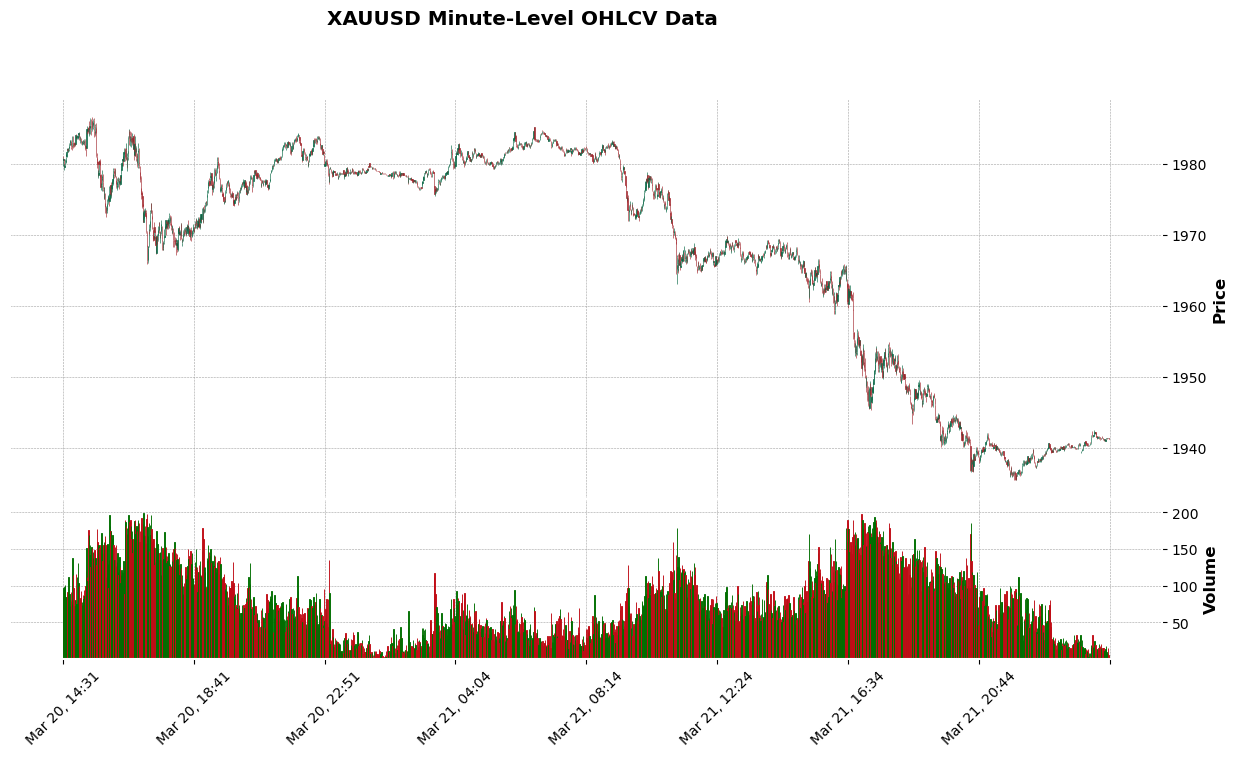

In [242]:
plot_ohlcv(
    ohlcv_data=ohlcv_window,
    title="XAUUSD Minute-Level OHLCV Data",
)

/opt/miniconda3/envs/quant_env/lib/python3.11/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


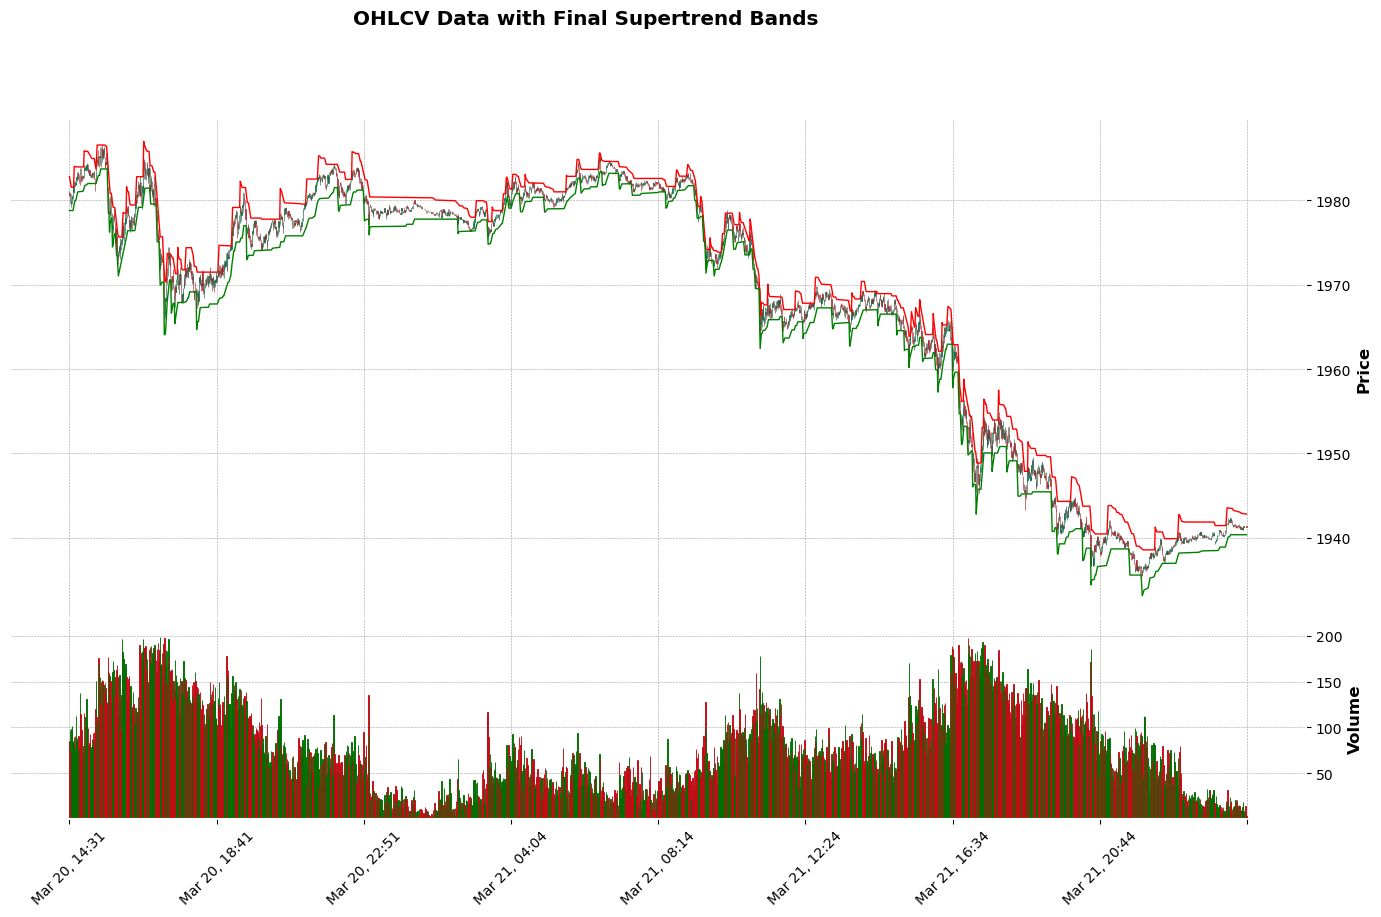

In [243]:
plot_ohlcv_with_supertrend_bands(
    supertrend_data=supertrend_window,
)

/opt/miniconda3/envs/quant_env/lib/python3.11/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


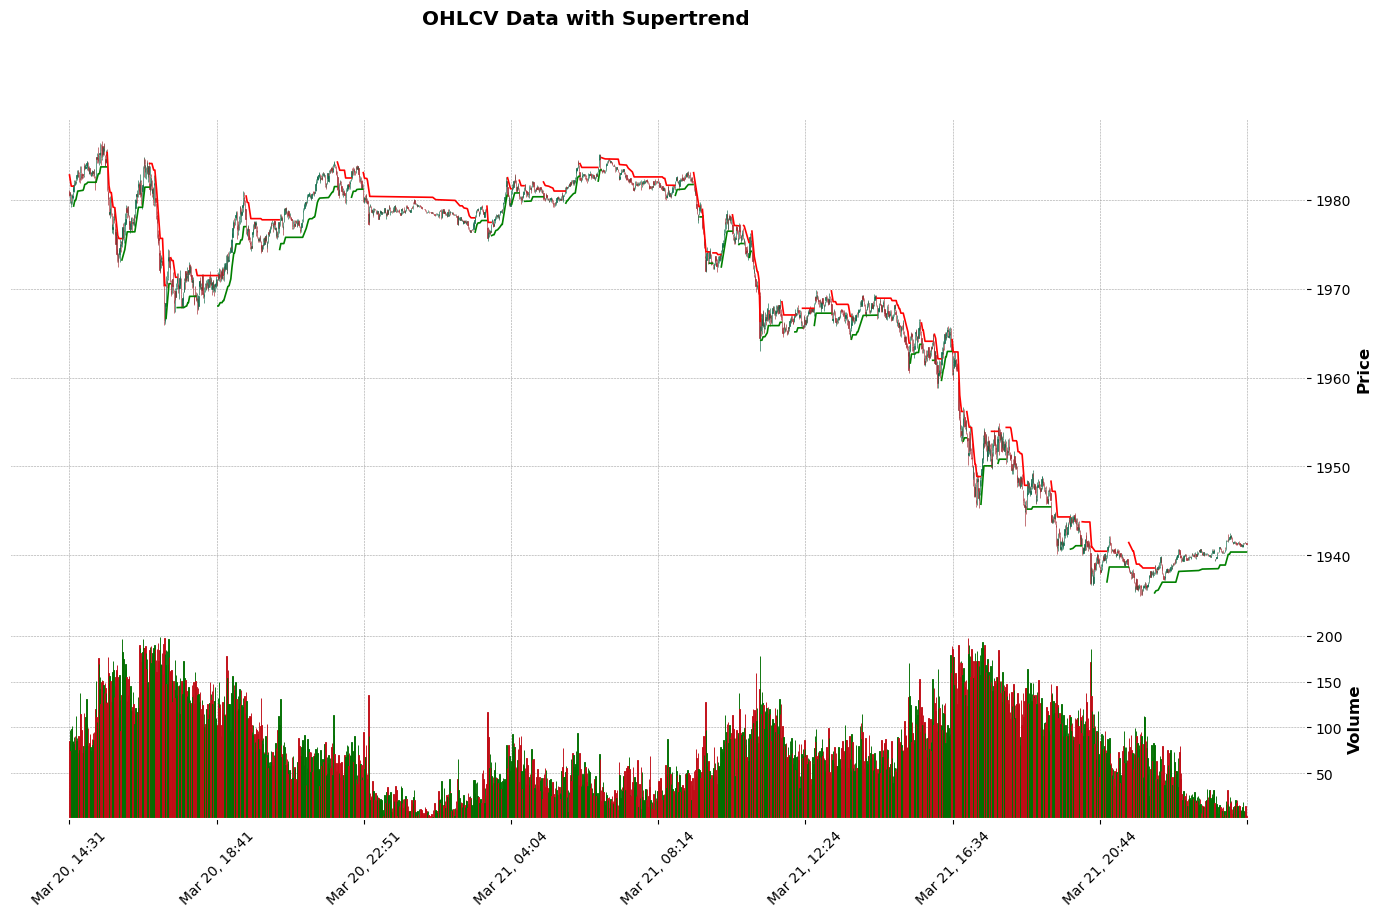

In [244]:
plot_ohlcv_with_supertrend(
    supertrend_data=supertrend_window,
)

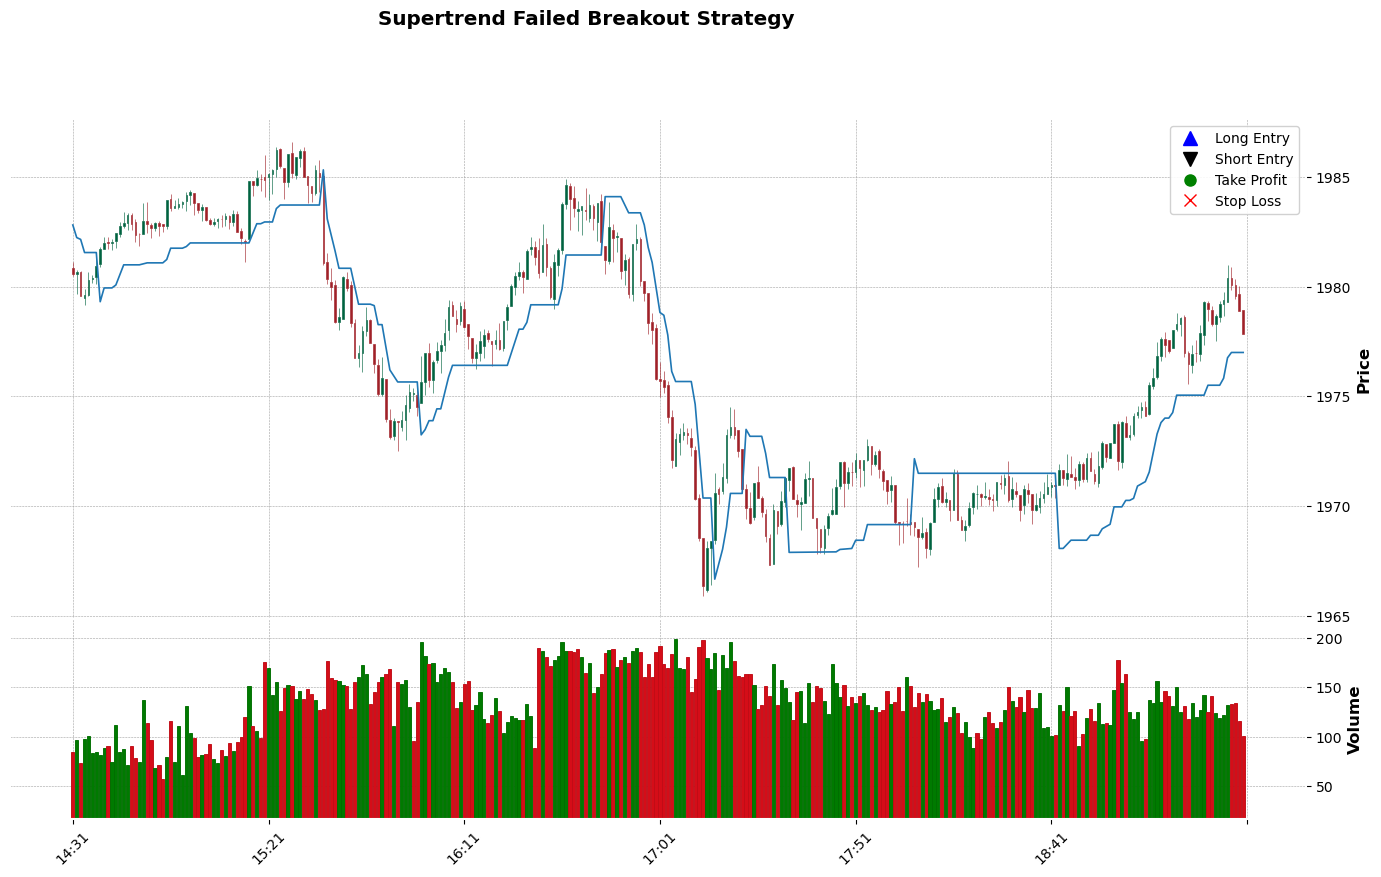

In [245]:
plot_strategy_trades(
    signal_data=signal_window.iloc[0:300],
    trades_data=trades_window,
)

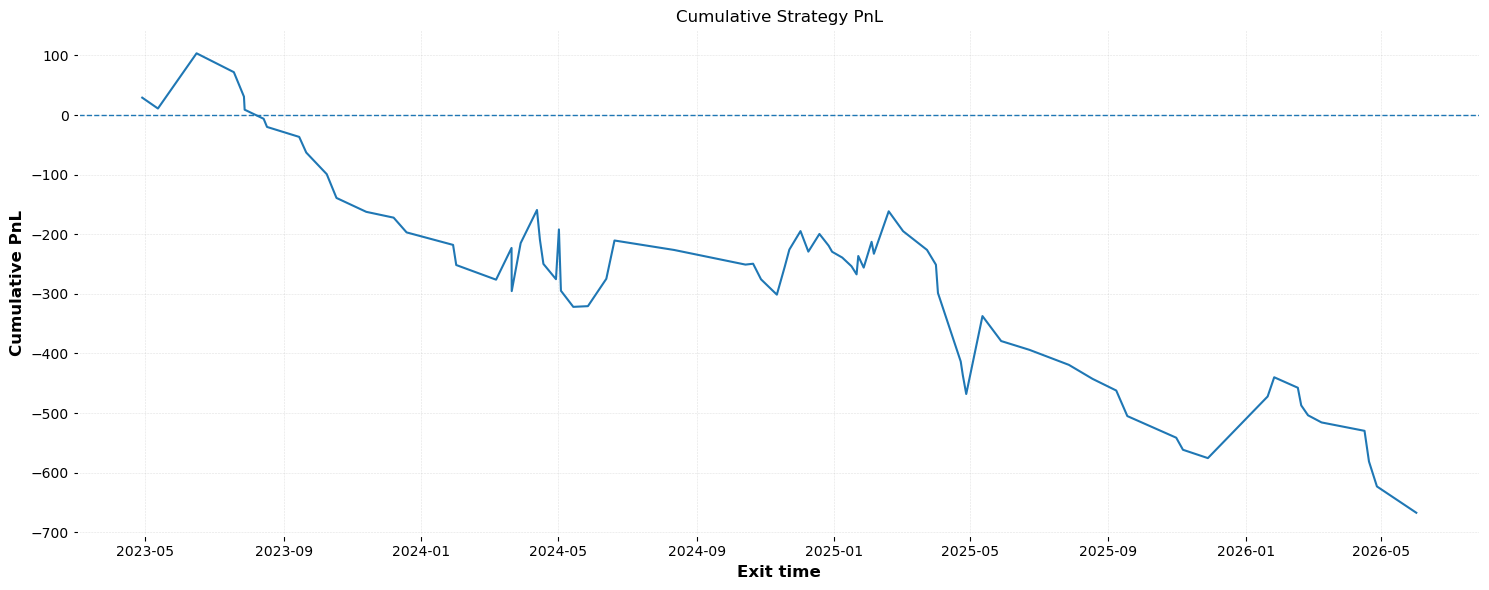

In [246]:
plot_cumulative_pnl(
    trades_data=trades_window
)

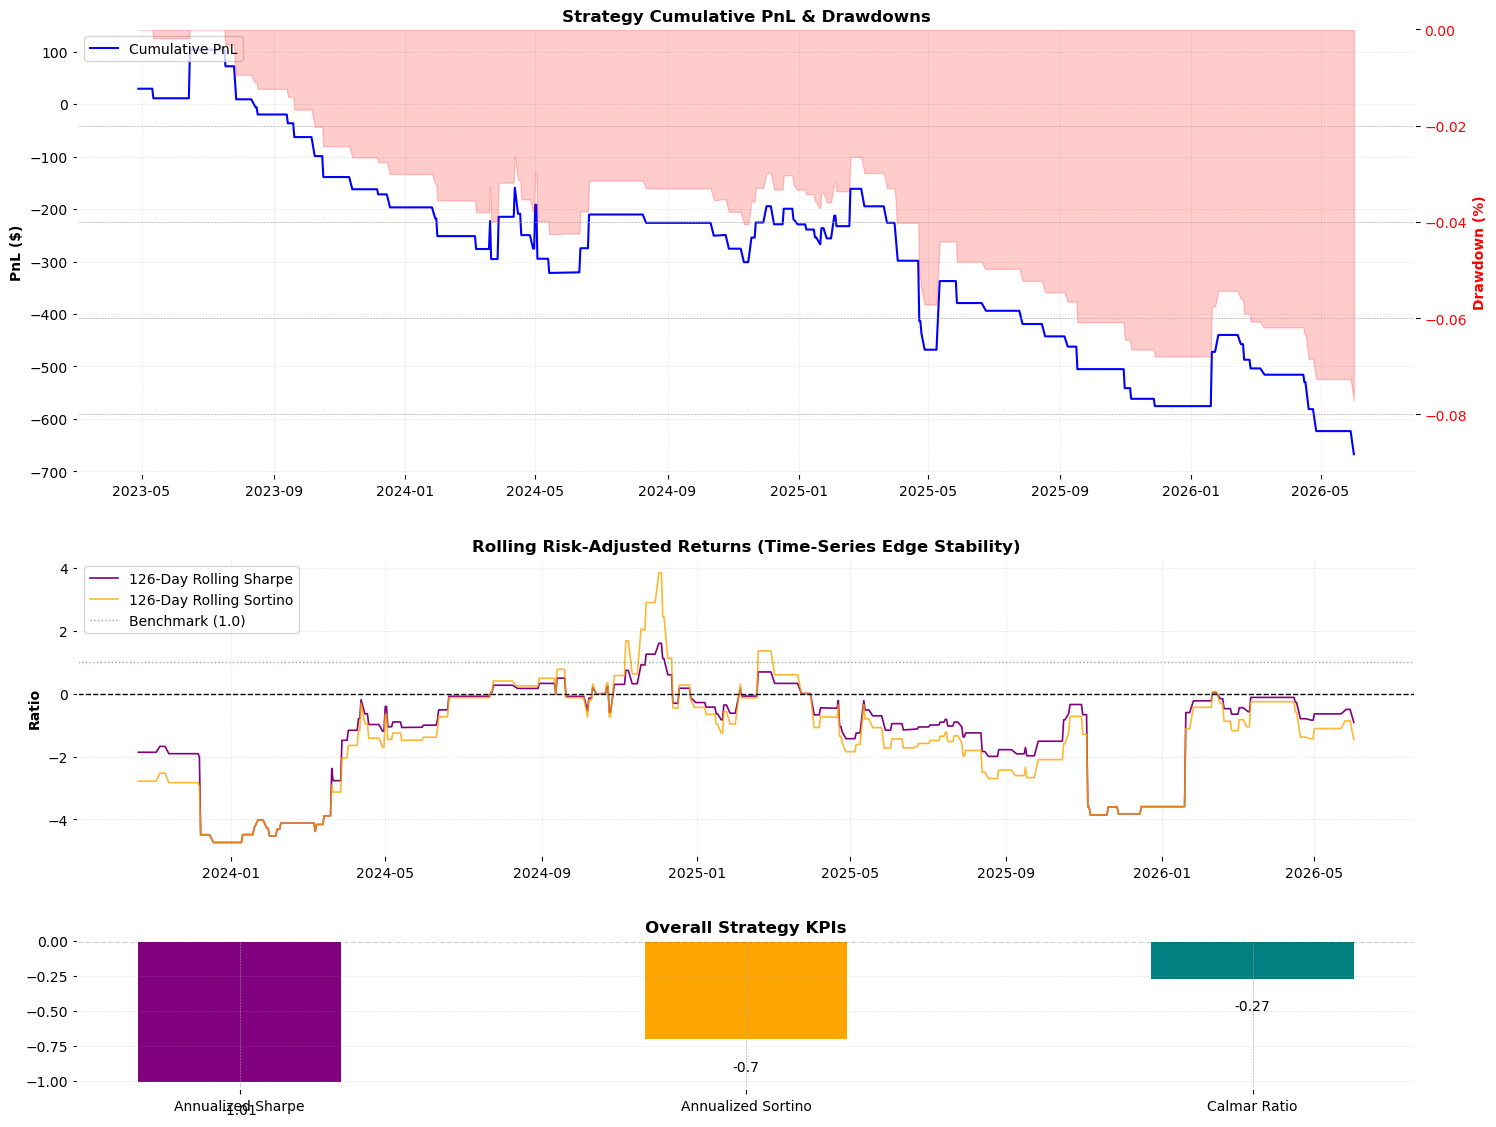

In [247]:
plot_strategy_performance(
    performance_plot_data=performance_plot_data,
    performance_metrics=performance_metrics,
    rolling_window_days=126, 
    trading_days_per_year=252,
    figsize=(15, 12)
)

In [248]:
print_performance_summary(performance_metrics=performance_metrics)

          STRATEGY PERFORMANCE TEAR SHEET

[ TRADE STATISTICS ]
--------------------------------------------------
Total Trades:           78
Win Rate:               25.64%
Profit Factor:          0.61
Average R-Multiple:     -0.76R

[ ABSOLUTE RETURNS ]
--------------------------------------------------
Total Net PnL:          $-667.23
Total Return:           -0.07%
Annualized Return:      -0.02%

[ RISK & RISK-ADJUSTED METRICS ]
--------------------------------------------------
Maximum Drawdown ($):   $770.87
Maximum Drawdown (%):   0.08%
Annualized Sharpe:      -1.01
Annualized Sortino:     -0.70
Calmar Ratio:           -0.27



In [249]:
signal_window.iloc[30:50]

,open,high,low,close,tick_volume,source_file,true_range,atr,basic_upper_band,basic_lower_band,final_upper_band,final_lower_band,supertrend,trend,volume_ma,long_signal,short_signal,breakout_price,signal_strength
time,,,,,,,,,,,,,,,,,,,
2023-03-20 15:01:00,1984.16,1984.38,1983.70,1984.32,104,XAUUSD_M1_2023.csv,0.68,0.684367,1986.093100,1981.986900,1985.789764,1981.986900,1981.986900,1.0,91.35,False,False,NaN,0.0
2023-03-20 15:02:00,1984.26,1984.26,1983.26,1983.82,99,XAUUSD_M1_2023.csv,1.06,0.686245,1985.818734,1981.701266,1985.789764,1981.986900,1981.986900,1.0,90.70,False,False,NaN,0.0
2023-03-20 15:03:00,1983.82,1983.82,1983.36,1983.47,80,XAUUSD_M1_2023.csv,0.46,0.685114,1985.645341,1981.534659,1985.645341,1981.986900,1981.986900,1.0,90.45,False,False,NaN,0.0
2023-03-20 15:04:00,1983.47,1983.76,1982.97,1983.64,82,XAUUSD_M1_2023.csv,0.79,0.685638,1985.421914,1981.308086,1985.421914,1981.986900,1981.986900,1.0,90.15,False,False,NaN,0.0
2023-03-20 15:05:00,1983.64,1983.64,1982.98,1983.05,83,XAUUSD_M1_2023.csv,0.66,0.685510,1985.366529,1981.253471,1985.366529,1981.986900,1981.986900,1.0,90.70,False,False,NaN,0.0
2023-03-20 15:06:00,1983.05,1983.14,1982.79,1982.85,93,XAUUSD_M1_2023.csv,0.35,0.683832,1985.016497,1980.913503,1985.016497,1981.986900,1981.986900,1.0,90.80,False,False,NaN,0.0
2023-03-20 15:07:00,1982.87,1983.12,1982.74,1982.94,78,XAUUSD_M1_2023.csv,0.38,0.682313,1984.976939,1980.883061,1984.976939,1981.986900,1981.986900,1.0,90.75,False,False,NaN,0.0
2023-03-20 15:08:00,1982.97,1983.13,1982.69,1983.10,74,XAUUSD_M1_2023.csv,0.44,0.681101,1984.953304,1980.866696,1984.953304,1981.986900,1981.986900,1.0,90.70,False,False,NaN,0.0
2023-03-20 15:09:00,1983.10,1983.27,1982.73,1983.06,87,XAUUSD_M1_2023.csv,0.54,0.680396,1985.041188,1980.958812,1984.953304,1981.986900,1981.986900,1.0,88.20,False,False,NaN,0.0


In [250]:
# 2. Extract the exact start and end timestamps from the signal window's index
start_time = signal_window.iloc[0:].index.min()
end_time = signal_window.iloc[0:].index.max()

# 3. Filter the trades dataframe to only include trades that entered during this window
trades_data[
    (trades_data["entry_time"] >= start_time) & 
    (trades_data["entry_time"] <= end_time)
]

,direction,entry_time,entry_price,stop_loss,take_profit,size,risk_per_share,entry_commission,exit_time,exit_price,exit_reason,pnl,r_multiple,running_capital


In [251]:
trades_data[(trades_data["exit_reason"] == "take_profit")]

,direction,entry_time,entry_price,stop_loss,take_profit,size,risk_per_share,entry_commission,exit_time,exit_price,exit_reason,pnl,r_multiple,running_capital
0,short,2023-04-28 06:25:00,1988.56,1991.17,1980.73,5,2.61,4.971400,2023-04-28 11:16:00,1980.73,take_profit,29.226775,2.239600,1.000029e+06
2,short,2023-06-14 21:01:00,1946.84,1953.66,1926.38,5,6.82,4.867100,2023-06-15 15:28:00,1926.38,take_profit,92.616950,2.716040,1.000104e+06
18,long,2024-03-20 21:01:00,2162.18,2157.02,2177.66,4,5.16,4.324360,2024-03-20 21:45:00,2177.66,take_profit,53.240320,2.579473,9.997771e+05
20,long,2024-03-28 13:23:00,2207.09,2199.64,2229.44,4,7.45,4.414180,2024-03-28 23:49:00,2229.44,take_profit,80.526940,2.702246,9.997852e+05
21,long,2024-04-12 04:01:00,2384.17,2378.74,2400.46,4,5.43,4.768340,2024-04-12 11:00:00,2400.46,take_profit,55.590740,2.559426,9.998408e+05
25,long,2024-05-01 21:01:00,2303.48,2295.75,2326.67,4,7.73,4.606960,2024-05-01 21:50:00,2326.67,take_profit,83.499700,2.700508,9.998081e+05
28,long,2024-05-27 14:49:00,2344.13,2343.25,2346.77,4,0.88,4.688260,2024-05-27 15:19:00,2346.77,take_profit,1.178200,0.334716,9.996794e+05
29,short,2024-06-12 21:01:00,2330.52,2335.12,2316.72,4,4.60,4.661040,2024-06-12 22:24:00,2316.72,take_profit,45.905520,2.494865,9.997253e+05
30,long,2024-06-18 15:31:00,2318.24,2312.11,2336.63,4,6.13,4.636480,2024-06-20 04:34:00,2336.63,take_profit,64.250260,2.620321,9.997896e+05
33,long,2024-10-21 01:01:00,2720.65,2719.58,2723.86,3,1.07,4.080975,2024-10-21 01:58:00,2723.86,take_profit,1.463235,0.455836,9.997506e+05


In [252]:
trades_data[(trades_data["exit_reason"] == "stop_loss")]

,direction,entry_time,entry_price,stop_loss,take_profit,size,risk_per_share,entry_commission,exit_time,exit_price,exit_reason,pnl,r_multiple,running_capital
1,long,2023-05-12 08:01:00,2011.04,2008.50,2018.66,4,2.54,4.022080,2023-05-12 09:12:00,2008.50,stop_loss,-18.199080,-1.791248,1.000011e+06
3,short,2023-07-18 14:18:00,1967.80,1972.16,1954.72,5,4.36,4.919500,2023-07-18 17:00:00,1972.16,stop_loss,-31.649900,-1.451830,1.000072e+06
4,long,2023-07-26 21:01:00,1972.25,1966.01,1990.97,5,6.24,4.930625,2023-07-27 15:41:00,1966.01,stop_loss,-41.045650,-1.315566,1.000031e+06
5,long,2023-07-28 06:29:00,1953.34,1950.91,1960.63,5,2.43,4.883350,2023-07-28 06:35:00,1950.91,stop_loss,-21.910625,-1.803344,1.000009e+06
6,long,2023-08-14 01:01:00,1913.47,1912.33,1916.89,5,1.14,4.783675,2023-08-14 03:04:00,1912.33,stop_loss,-15.264500,-2.677982,9.999938e+05
7,long,2023-08-17 02:02:00,1894.00,1893.16,1896.52,5,0.84,4.735000,2023-08-17 02:25:00,1893.16,stop_loss,-13.667900,-3.254262,9.999801e+05
8,long,2023-09-14 15:16:00,1907.95,1906.51,1912.27,5,1.44,4.769875,2023-09-14 15:30:00,1906.51,stop_loss,-16.736150,-2.324465,9.999634e+05
9,short,2023-09-20 21:01:00,1942.73,1946.04,1932.80,5,3.31,4.856825,2023-09-20 21:31:00,1946.04,stop_loss,-26.271925,-1.587427,9.999371e+05
10,long,2023-10-09 01:04:00,1854.58,1849.19,1870.75,5,5.39,4.636450,2023-10-09 01:16:00,1849.19,stop_loss,-36.209425,-1.343578,9.999009e+05
11,short,2023-10-16 01:01:00,1923.51,1929.57,1905.33,5,6.06,4.808775,2023-10-17 16:47:00,1929.57,stop_loss,-39.932700,-1.317911,9.998610e+05
